# Redes Convolucionales

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from datasets import load_dataset

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.13.2


## Dataset

In [ ]:
ds = load_dataset("uoft-cs/cifar10")
print(ds)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
LABELS = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

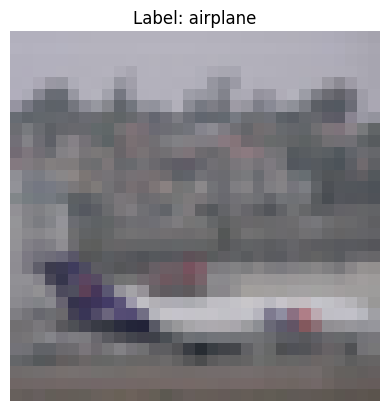

In [ ]:
ds_train = ds['train']
ds_test = ds['test']

plt.imshow(ds_train[0]['img'])
plt.title(f'Label: {LABELS[ds_train[0]['label']]}')
plt.axis('off')
plt.show()

extraemos todo el dataset a memoria y normalizamos las imágenes al rango [0, 1]

In [ ]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0